Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


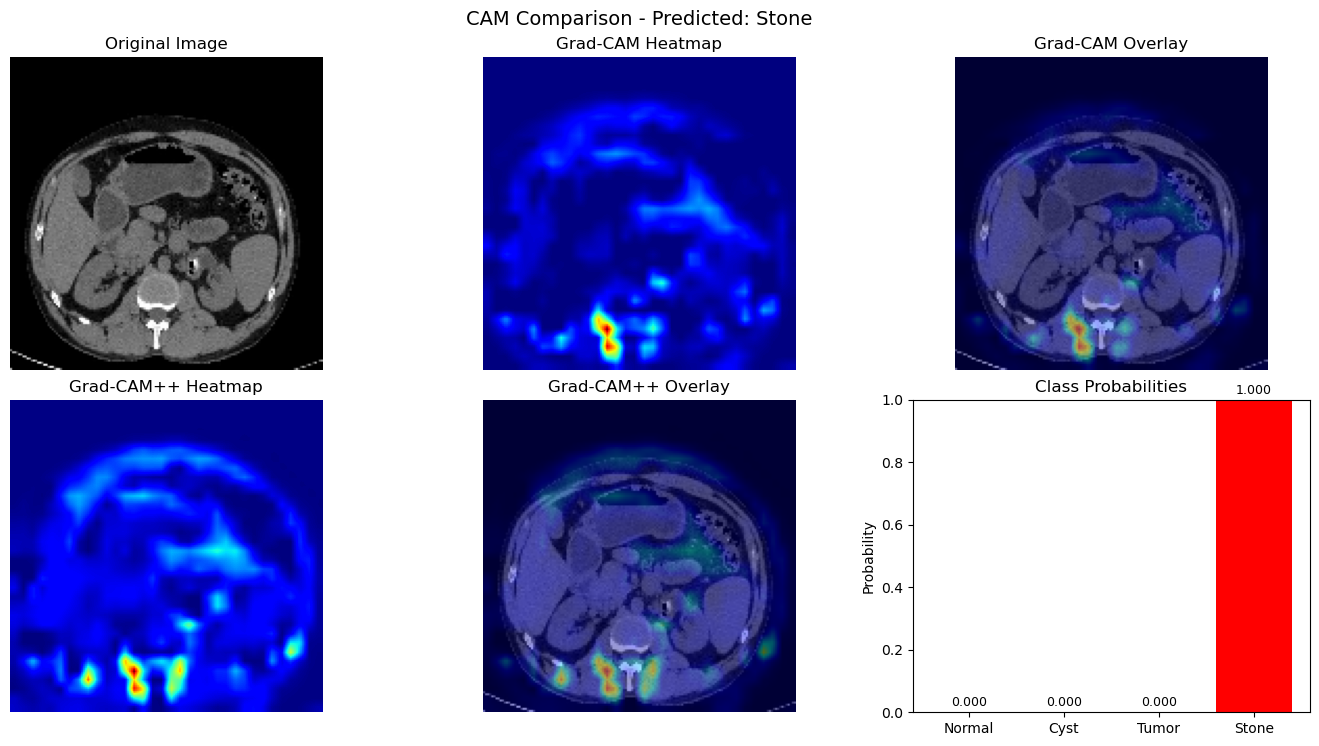

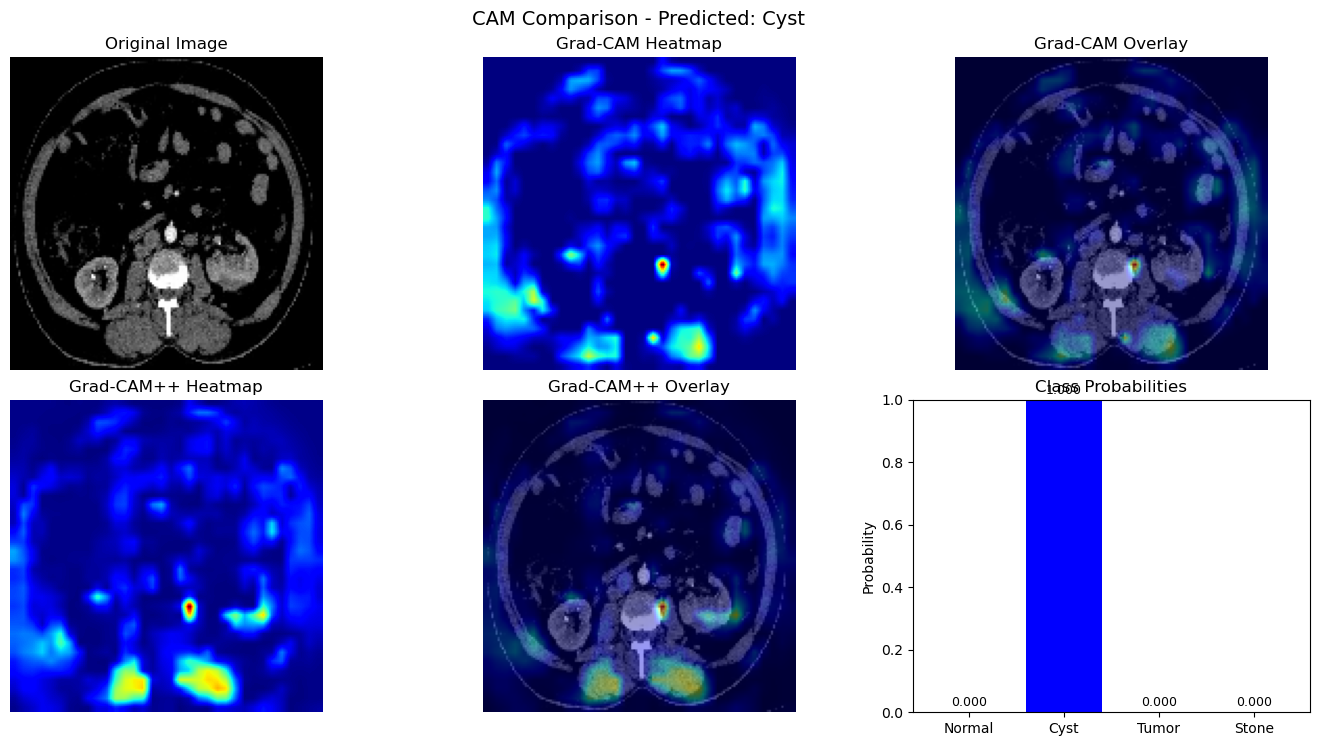

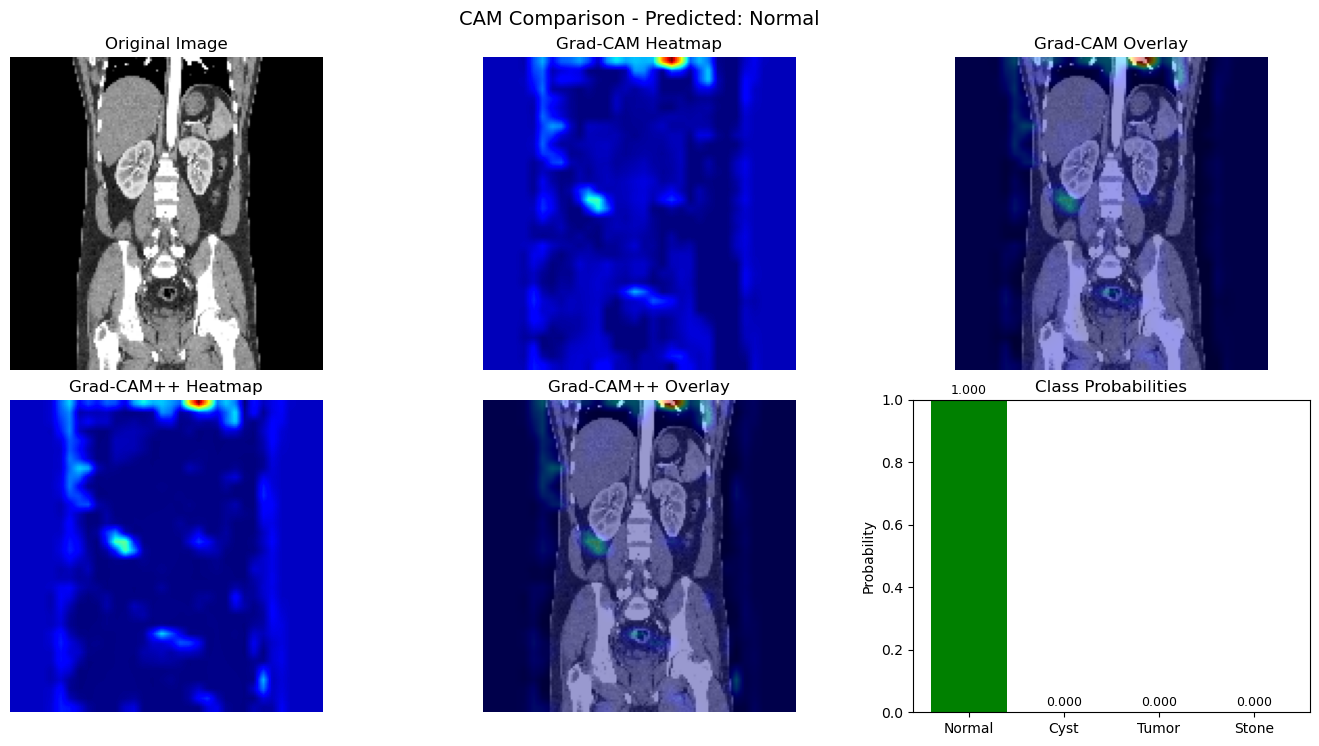

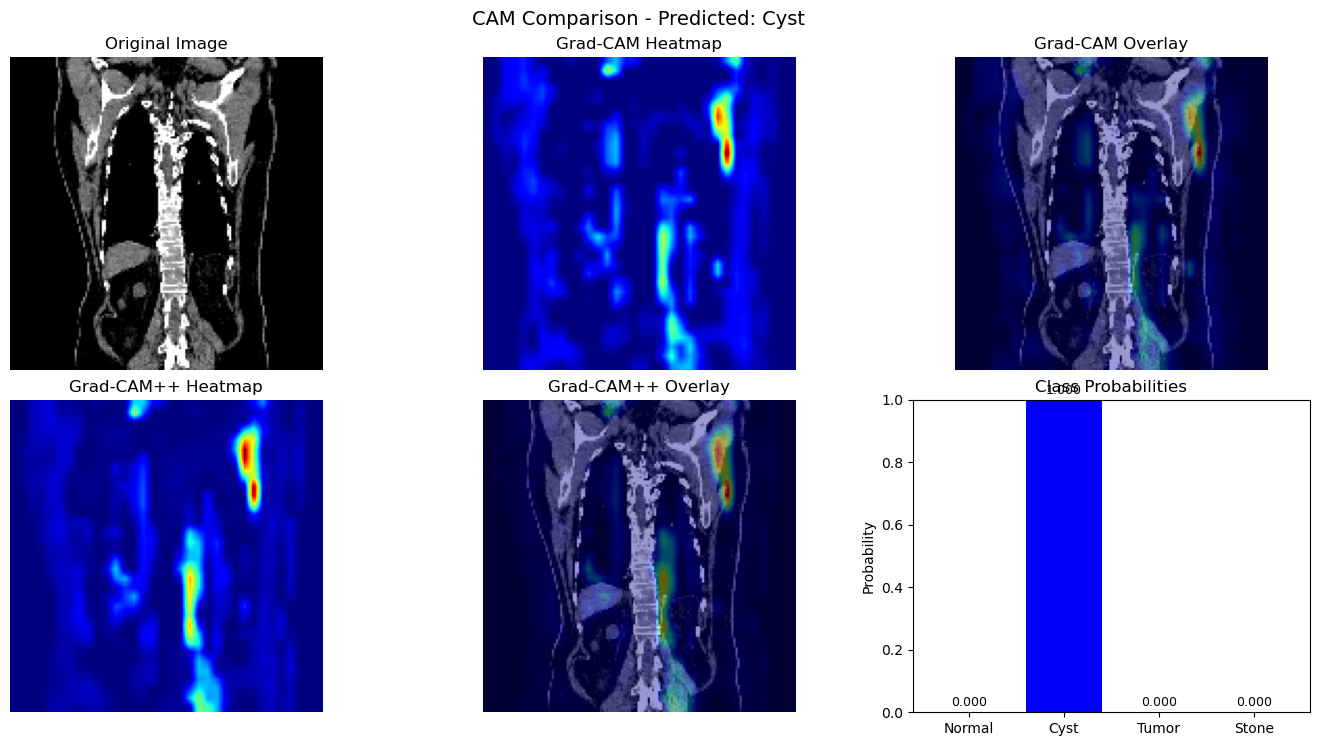

In [3]:
import tkinter as tk
from tkinter import filedialog, messagebox, ttk
from PIL import Image, ImageTk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
import tensorflow as tf
import cv2

# --- Constants ---
MODEL_PATH = "cnn_bilstm_kidney_classification (1).h5"  # Path to the trained model
IMG_SIZE = 150  # Image size expected by the model
CLASSES = ['Normal', 'Cyst', 'Tumor', 'Stone']  # Class labels
PASSWORD = "yasir"  # Password for login

# Load the pre-trained model
try:
    model = load_model(MODEL_PATH)
    print("Model loaded successfully!")
except Exception as e:
    messagebox.showerror("Error", f"Failed to load model:\n{e}")
    exit()

# ==================== CAM FUNCTIONS ====================

def get_last_conv_layer():
    """Get the last convolutional layer of the model"""
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

def grad_cam(img_array, target_class=None):
    """
    Generate standard Grad-CAM heatmap for a single image
    """
    # Get the last convolutional layer
    last_conv_name = get_last_conv_layer()
    if last_conv_name is None:
        return None, None, None
    
    last_conv_layer = model.get_layer(last_conv_name)
    
    # Create a model that outputs the last conv layer and the final predictions
    grad_model = Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )
    
    # Ensure correct input shape
    if len(img_array.shape) == 3:
        img_input = np.expand_dims(img_array, axis=0)
    else:
        img_input = img_array
    
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_input)
        
        if target_class is None:
            target_class = tf.argmax(predictions[0])
        elif isinstance(target_class, (int, np.integer)):
            target_class = tf.constant(target_class)
        
        loss = predictions[:, target_class]
    
    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))
    
    conv_output = conv_output[0]
    pooled_grads = pooled_grads[0]
    
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output), axis=-1)
    heatmap = np.maximum(heatmap.numpy(), 0)
    
    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)
    
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    
    return heatmap_resized, target_class.numpy() if hasattr(target_class, 'numpy') else target_class, predictions[0].numpy()

def grad_cam_plus_plus(img_array, target_class=None):
    """
    Generate Grad-CAM++ heatmap for a single image
    """
    # Get the last convolutional layer
    last_conv_name = get_last_conv_layer()
    if last_conv_name is None:
        return None, None, None
    
    last_conv_layer = model.get_layer(last_conv_name)
    
    # Create a model that outputs the last conv layer and the final predictions
    grad_model = Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )
    
    # Ensure correct input shape
    if len(img_array.shape) == 3:
        img_input = np.expand_dims(img_array, axis=0)
    else:
        img_input = img_array
    
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_input)
        
        if target_class is None:
            target_class = tf.argmax(predictions[0])
        elif isinstance(target_class, (int, np.integer)):
            target_class = tf.constant(target_class)
        
        loss = predictions[:, target_class]
    
    grads = tape.gradient(loss, conv_output)
    conv_output = conv_output[0]
    first_grads = grads[0]
    
    # Grad-CAM++ calculation
    grads_squared = tf.square(first_grads)
    grads_cubed = tf.pow(first_grads, 3)
    
    denominator = tf.reduce_sum(grads_squared, axis=(0, 1)) + tf.reduce_sum(conv_output * grads_cubed, axis=(0, 1))
    denominator = denominator + 1e-8
    
    alpha = tf.reduce_sum(grads_squared, axis=(0, 1)) / denominator
    weights = tf.reduce_sum(alpha * tf.nn.relu(first_grads), axis=(0, 1))
    
    heatmap = tf.reduce_sum(tf.multiply(weights, conv_output), axis=-1)
    heatmap = np.maximum(heatmap.numpy(), 0)
    
    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)
    
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    
    return heatmap_resized, target_class.numpy() if hasattr(target_class, 'numpy') else target_class, predictions[0].numpy()

def create_cam_overlay(img_array, heatmap):
    """
    Create overlay of heatmap on original image
    """
    # Convert image to uint8
    if img_array.max() <= 1.0:
        img_uint8 = (img_array * 255).astype(np.uint8)
    else:
        img_uint8 = img_array.astype(np.uint8)
    
    # Create heatmap in color
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Superimpose heatmap on original image
    superimposed = cv2.addWeighted(img_uint8, 0.6, heatmap_colored, 0.4, 0)
    
    return superimposed

# --- Functions ---
def load_and_predict():
    """Load an image file, preprocess it, and predict its class."""
    file_path = filedialog.askopenfilename(
        filetypes=[("Image Files", "*.jpg *.jpeg *.png")]
    )
    if not file_path:
        return

    try:
        # Preprocess the image
        img = load_img(file_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = img_to_array(img) / 255.0
        img_array_input = np.expand_dims(img_array, axis=0)

        # Predict the class
        predictions = model.predict(img_array_input)
        predicted_class = np.argmax(predictions[0])
        predicted_class_name = CLASSES[predicted_class]

        # Generate CAM visualizations
        heatmap_gradcam, _, _ = grad_cam(img_array, predicted_class)
        heatmap_gradcampp, _, _ = grad_cam_plus_plus(img_array, predicted_class)
        
        # Create overlays
        overlay_gradcam = create_cam_overlay(img_array, heatmap_gradcam)
        overlay_gradcampp = create_cam_overlay(img_array, heatmap_gradcampp)

        # Display the image and visualizations
        display_image_and_cam(file_path, predicted_class_name, predictions[0], 
                            img_array, heatmap_gradcam, heatmap_gradcampp, 
                            overlay_gradcam, overlay_gradcampp, predicted_class)
    except Exception as e:
        messagebox.showerror("Error", f"An error occurred:\n{e}")

def display_image_and_cam(file_path, predicted_class_name, probabilities, 
                         img_array, heatmap_gc, heatmap_gcpp, overlay_gc, overlay_gcpp, predicted_class):
    """Display the selected image, predictions, and CAM visualizations in a new window."""
    
    # Create a new window for CAM visualization
    cam_window = tk.Toplevel()
    cam_window.title("Grad-CAM Visualization - Kidney Disease Classification")
    cam_window.geometry("1400x800")
    cam_window.configure(bg="#f0f0f0")
    
    # Create a notebook for tabs
    notebook = ttk.Notebook(cam_window)
    notebook.pack(fill='both', expand=True, padx=10, pady=10)
    
    # Tab 1: Original Image with Prediction
    tab1 = ttk.Frame(notebook)
    notebook.add(tab1, text="Original Image")
    
    # Tab 2: Grad-CAM Visualization
    tab2 = ttk.Frame(notebook)
    notebook.add(tab2, text="Grad-CAM")
    
    # Tab 3: Grad-CAM++ Visualization
    tab3 = ttk.Frame(notebook)
    notebook.add(tab3, text="Grad-CAM++")
    
    # Tab 4: Comparison
    tab4 = ttk.Frame(notebook)
    notebook.add(tab4, text="Comparison")
    
    # ==================== Tab 1: Original Image ====================
    # Load and display original image
    original_img = Image.open(file_path).convert("RGB")
    original_img.thumbnail((400, 400))
    img_tk = ImageTk.PhotoImage(original_img)
    
    img_label = tk.Label(tab1, image=img_tk, bg="white")
    img_label.image = img_tk
    img_label.pack(pady=20)
    
    # Prediction text
    pred_text = f"Predicted Class: {predicted_class_name}\n\nClass Probabilities:\n"
    for i, class_name in enumerate(CLASSES):
        pred_text += f"{class_name}: {probabilities[i]:.4f}\n"
    
    pred_label = tk.Label(tab1, text=pred_text, font=("Arial", 14), 
                          bg="#f0f0f0", justify="left")
    pred_label.pack(pady=20)
    
    # ==================== Tab 2: Grad-CAM ====================
    # Original image for display
    img_uint8 = (img_array * 255).astype(np.uint8)
    img_pil = Image.fromarray(img_uint8)
    img_pil.thumbnail((400, 400))
    img_tk2 = ImageTk.PhotoImage(img_pil)
    
    # Heatmap display
    heatmap_pil = Image.fromarray(np.uint8(255 * heatmap_gc))
    heatmap_pil.thumbnail((400, 400))
    heatmap_tk = ImageTk.PhotoImage(heatmap_pil)
    
    # Overlay display
    overlay_pil = Image.fromarray(overlay_gc)
    overlay_pil.thumbnail((400, 400))
    overlay_tk = ImageTk.PhotoImage(overlay_pil)
    
    # Create frames for Grad-CAM tab
    frame_gc = tk.Frame(tab2, bg="#f0f0f0")
    frame_gc.pack(expand=True, fill='both')
    
    # Original image in Grad-CAM tab
    tk.Label(frame_gc, text="Original Image", font=("Arial", 12, "bold"), 
             bg="#f0f0f0").grid(row=0, column=0, padx=10, pady=5)
    tk.Label(frame_gc, image=img_tk2, bg="white").grid(row=1, column=0, padx=10, pady=5)
    
    # Heatmap
    tk.Label(frame_gc, text="Grad-CAM Heatmap", font=("Arial", 12, "bold"), 
             bg="#f0f0f0").grid(row=0, column=1, padx=10, pady=5)
    tk.Label(frame_gc, image=heatmap_tk, bg="white").grid(row=1, column=1, padx=10, pady=5)
    
    # Overlay
    tk.Label(frame_gc, text="Grad-CAM Overlay", font=("Arial", 12, "bold"), 
             bg="#f0f0f0").grid(row=0, column=2, padx=10, pady=5)
    tk.Label(frame_gc, image=overlay_tk, bg="white").grid(row=1, column=2, padx=10, pady=5)
    
    # Keep references
    frame_gc.img_tk2 = img_tk2
    frame_gc.heatmap_tk = heatmap_tk
    frame_gc.overlay_tk = overlay_tk
    
    # ==================== Tab 3: Grad-CAM++ ====================
    # Heatmap display for Grad-CAM++
    heatmappp_pil = Image.fromarray(np.uint8(255 * heatmap_gcpp))
    heatmappp_pil.thumbnail((400, 400))
    heatmappp_tk = ImageTk.PhotoImage(heatmappp_pil)
    
    # Overlay display for Grad-CAM++
    overlaypp_pil = Image.fromarray(overlay_gcpp)
    overlaypp_pil.thumbnail((400, 400))
    overlaypp_tk = ImageTk.PhotoImage(overlaypp_pil)
    
    # Create frames for Grad-CAM++ tab
    frame_gcpp = tk.Frame(tab3, bg="#f0f0f0")
    frame_gcpp.pack(expand=True, fill='both')
    
    # Original image in Grad-CAM++ tab
    tk.Label(frame_gcpp, text="Original Image", font=("Arial", 12, "bold"), 
             bg="#f0f0f0").grid(row=0, column=0, padx=10, pady=5)
    tk.Label(frame_gcpp, image=img_tk2, bg="white").grid(row=1, column=0, padx=10, pady=5)
    
    # Heatmap
    tk.Label(frame_gcpp, text="Grad-CAM++ Heatmap", font=("Arial", 12, "bold"), 
             bg="#f0f0f0").grid(row=0, column=1, padx=10, pady=5)
    tk.Label(frame_gcpp, image=heatmappp_tk, bg="white").grid(row=1, column=1, padx=10, pady=5)
    
    # Overlay
    tk.Label(frame_gcpp, text="Grad-CAM++ Overlay", font=("Arial", 12, "bold"), 
             bg="#f0f0f0").grid(row=0, column=2, padx=10, pady=5)
    tk.Label(frame_gcpp, image=overlaypp_tk, bg="white").grid(row=1, column=2, padx=10, pady=5)
    
    # Keep references
    frame_gcpp.img_tk2 = img_tk2
    frame_gcpp.heatmappp_tk = heatmappp_tk
    frame_gcpp.overlaypp_tk = overlaypp_tk
    
    # ==================== Tab 4: Comparison ====================
    # Create matplotlib figure for comparison
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f'CAM Comparison - Predicted: {predicted_class_name}', fontsize=14)
    
    # Original image
    axes[0, 0].imshow(img_uint8)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Grad-CAM heatmap
    axes[0, 1].imshow(heatmap_gc, cmap='jet')
    axes[0, 1].set_title('Grad-CAM Heatmap')
    axes[0, 1].axis('off')
    
    # Grad-CAM overlay
    axes[0, 2].imshow(overlay_gc)
    axes[0, 2].set_title('Grad-CAM Overlay')
    axes[0, 2].axis('off')
    
    # Grad-CAM++ heatmap
    axes[1, 0].imshow(heatmap_gcpp, cmap='jet')
    axes[1, 0].set_title('Grad-CAM++ Heatmap')
    axes[1, 0].axis('off')
    
    # Grad-CAM++ overlay
    axes[1, 1].imshow(overlay_gcpp)
    axes[1, 1].set_title('Grad-CAM++ Overlay')
    axes[1, 1].axis('off')
    
    # Class probabilities bar chart
    axes[1, 2].bar(CLASSES, probabilities, color=['green', 'blue', 'orange', 'red'])
    axes[1, 2].set_title('Class Probabilities')
    axes[1, 2].set_ylabel('Probability')
    axes[1, 2].set_ylim([0, 1])
    for i, prob in enumerate(probabilities):
        axes[1, 2].text(i, prob + 0.02, f'{prob:.3f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    
    # Embed matplotlib figure in tkinter
    canvas = FigureCanvasTkAgg(fig, master=tab4)
    canvas.draw()
    canvas.get_tk_widget().pack(expand=True, fill='both')
    
    # Add interpretation text
    interpretation = f"""
    ==================== CAM INTERPRETATION ====================
    
    Prediction: {predicted_class_name}
    Confidence: {probabilities[predicted_class]:.4f}
    
    The heatmaps show which regions of the CT image influenced the model's decision:
    • Red/Orange regions: High importance for classification
    • Blue/Green regions: Low importance for classification
    
    Grad-CAM vs Grad-CAM++:
    • Grad-CAM: Shows broader activation areas
    • Grad-CAM++: Provides sharper boundaries and better localization
    
    For this {predicted_class_name} case:
    """
    
    if predicted_class_name == "Normal":
        interpretation += "\n    ✓ The model is focusing on normal kidney structures"
    elif predicted_class_name == "Cyst":
        interpretation += "\n    ✓ The model is focusing on cystic regions (fluid-filled sacs)"
    elif predicted_class_name == "Tumor":
        interpretation += "\n    ✓ The model is focusing on tumor regions (abnormal tissue growth)"
    elif predicted_class_name == "Stone":
        interpretation += "\n    ✓ The model is focusing on stone regions (calcified deposits)"
    
    interp_label = tk.Label(cam_window, text=interpretation, font=("Arial", 10), 
                            bg="#f0f0f0", justify="left", wraplength=800)
    interp_label.pack(pady=10)

def check_password():
    """Verify the password and open the main application if correct."""
    entered_password = password_entry.get()
    if entered_password == PASSWORD:
        login_window.destroy()
        open_main_application()
    else:
        messagebox.showerror("Error", "Incorrect password. Please try again.")

def open_main_application():
    """Launch the main application window."""
    global image_label, result_label

    root = tk.Tk()
    root.title("Automated Classification of Multi-Class Kidney CT Image By AI")
    root.geometry("600x700")
    root.configure(bg="#d8e2dc")

    # Title label
    title_label = tk.Label(
        root, text="Automated Classification of\nMulti-Class Kidney Disease",
        font=("Arial", 20, "bold"), fg="#264653", bg="#d8e2dc"
    )
    title_label.pack(pady=10)

    # Credits label
    credits_label = tk.Label(
        root, text="CNN-BiLSTM Model with CAM Visualization",
        font=("Arial", 12, "italic"), fg="#2a9d8f", bg="#d8e2dc"
    )
    credits_label.pack(pady=5)

    # Load image button
    load_button = tk.Button(
        root, text="Load CT Image", command=load_and_predict,
        font=("Arial", 14, "bold"), bg="#2a9d8f", fg="#ffffff", relief="raised",
        padx=20, pady=10
    )
    load_button.pack(pady=20)

    # Image display area
    image_label = tk.Label(root, bg="#ffffff", relief="sunken", width=400, height=400)
    image_label.pack(pady=10)

    # Prediction result area
    result_label = tk.Label(root, text="", font=("Arial", 12), justify="center", 
                            bg="#d8e2dc", wraplength=500)
    result_label.pack(pady=20)

    # Info label
    info_label = tk.Label(
        root, text="Note: After prediction, CAM visualizations will appear in a new window",
        font=("Arial", 9), fg="#e76f51", bg="#d8e2dc"
    )
    info_label.pack(pady=5)

    root.mainloop()

# --- Login Window ---
login_window = tk.Tk()
login_window.title("Login - Kidney Disease Classification System")
login_window.geometry("400x250")
login_window.configure(bg="#edf2f4")

# Title
title_label = tk.Label(login_window, text="Kidney Disease Classification System", 
                       font=("Arial", 16, "bold"), bg="#edf2f4", fg="#264653")
title_label.pack(pady=20)

# Password label and entry
password_label = tk.Label(login_window, text="Enter Password:", font=("Arial", 12), bg="#edf2f4")
password_label.pack(pady=10)

password_entry = tk.Entry(login_window, show="*", font=("Arial", 12), width=20)
password_entry.pack(pady=10)
password_entry.bind('<Return>', lambda event: check_password())

# Submit button
submit_button = tk.Button(
    login_window, text="Login", command=check_password,
    font=("Arial", 12, "bold"), bg="#2a9d8f", fg="#ffffff", relief="groove",
    padx=20, pady=5
)
submit_button.pack(pady=20)

login_window.mainloop()